In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.distributions import Normal, MultivariateNormal
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import wandb

\begin{equation*}
    p(x_1|x) = \frac{p_t(x,x_1)}{p_t(x)} = \frac{p_t(x|x_1)p(x_1)}{\int p_t(x|x_1)p(x_1) dx_1}
\end{equation*}

In [2]:
def ut_x_x1(x: torch.Tensor, x_1: torch.Tensor, gt: torch.Tensor, gt_prime: torch.Tensor):
    ### source: https://diffusion.csail.mit.edu/docs/lecture-notes.pdf example 11, equation 21
    p2 = -gt_prime/(1 - gt + 1e-3)
    return (gt_prime - p2*gt)*x_1 + p2*x

class Regular_t(nn.Module):
    '''
    just regular t to ensure it works in gaussian setting
    '''
    def __init__(
        self 
    ) -> None:
        super().__init__()

    def forward(self, t : Tensor) -> Tensor:
        return t


Case 1: $\theta$ is fixed, $\phi$ needs to learn

$q_t^\theta (x_1|x) = p(x_1|x)$

Target

$x_1 \sim \mathcal{N}(\tilde{\mu}, \tilde{\sigma}^2 I)$

Interpolant 

$x_t|x_1 \sim \mathcal{N}(\alpha_t x_1, \beta_t^2 I)$

Joint

$x_1, x_t \sim \mathcal{N}\left[\begin{pmatrix}
\tilde{\mu} \\
\alpha_t\tilde{\mu} 
\end{pmatrix}, \begin{pmatrix}
\tilde{\sigma}^2 & \alpha_t\tilde{\sigma}^2 \\
\alpha_t\tilde{\sigma}^2 & \alpha_t^2\tilde{\sigma}^2 + \beta_t^2
\end{pmatrix} \right]$

Marginal

$x_t \sim \mathcal{N}(\alpha_t\tilde{\mu},\alpha_t^2\tilde{\sigma}^2 + \beta_t^2)$

Posterior

$x_1|x_t \sim \mathcal{N}\left(\tilde{\mu} + \frac{\alpha_t\tilde{\sigma}^2}{\alpha_t^2\tilde{\sigma}^2 + \beta_t^2} (x_t - \alpha_t\tilde{\mu}), \;\;\;
\tilde{\sigma}^2 - \frac{(\alpha_t\tilde{\sigma}^2)^2}{\alpha_t^2\tilde{\sigma}^2 + \beta_t^2}  
\right)
$

In [3]:
## define distributions

## conditional distribution x_t
def pxt_given_x1(x1, alpha, beta2): return Normal(alpha*x1, torch.sqrt(beta2))

## marginal x_t
def pxt(mu, sigma2, alpha, beta2): return Normal(torch.tensor(alpha*mu), torch.sqrt(((alpha**2) * sigma2) + beta2))

## joint x1, xt
def px1_xt(mu, sigma2, alpha, beta2):
    mean_vector = torch.tensor([mu, alpha*mu])
    covariance = torch.tensor([[sigma2, alpha * sigma2], 
                               [alpha * sigma2, (alpha**2) * sigma2 + beta2]])
    return MultivariateNormal(mean_vector, covariance)

## posterior distribution
def p_x1_given_xt(mu, sigma2, alpha, beta2, xt):
    p1 = alpha * sigma2 / ((alpha**2) * sigma2 + beta2)
    p2 = xt - alpha*mu
    p3 = (alpha**2) * sigma2
    p4 = (alpha**2) * sigma2 + beta2
    return Normal(mu + p1 * p2, torch.sqrt(sigma2 - ((p3**2) / p4)))
    
# plt.hist(x1[:,0].detach().numpy())
# plt.show()

tensor(0., dtype=torch.float64) tensor(1., dtype=torch.float64)
-0.010686480804642368 1.0211187644098978
tensor(0.8000, dtype=torch.float64) tensor(0.8000, dtype=torch.float64)
0.7827506335167422 0.7554038222486651
tensor(1.6000, dtype=torch.float64) tensor(1., dtype=torch.float64)
1.5947211296656296 1.1029687810199011
tensor(2.4000, dtype=torch.float64) tensor(1.6000, dtype=torch.float64)
2.453765496699219 1.7481499847402957
tensor(3.2000, dtype=torch.float64) tensor(2.6000, dtype=torch.float64)
3.1100744643817095 2.649466167905183
tensor(4., dtype=torch.float64) tensor(4., dtype=torch.float64)
4.080612708712431 4.19651502345683


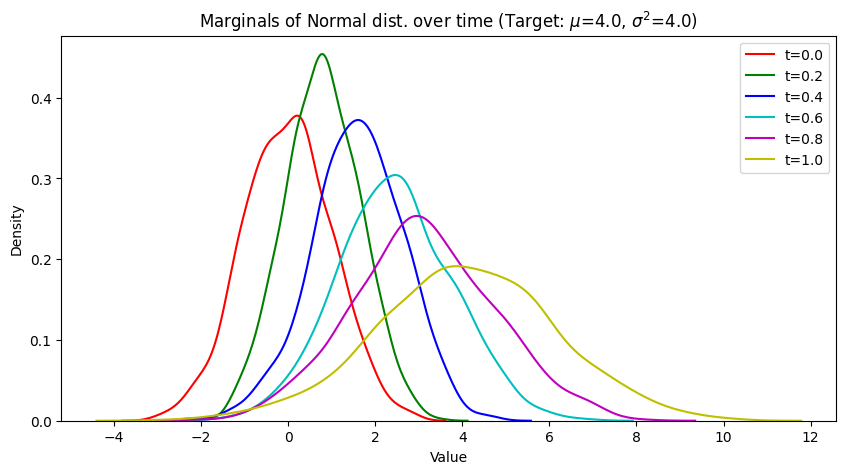

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

mu_target = 4.
sigma2_target = 4.

# Initialize the figure
plt.figure(figsize=(10, 5))

# Define the range for mu
t_s = np.linspace(0, 1, 6)  # mu will go from 1 to 5

# Set different colors for each histogram
colors = ['r', 'g', 'b', 'c', 'm', 
          'y', 'k', 'w', 'orange', 'purple']

# Loop over each mu value, generate samples, and update the histogram
for t, color in zip(t_s, colors):
    alpha = t
    alpha2 = t**2
    
    beta = 1 - t
    beta2 = torch.tensor(beta**2)
    # Generate mu random samples (randn generates samples from N(0,1))
    p_xt = pxt(mu_target, sigma2_target, alpha, beta2)
    x = p_xt.rsample((1000,1)).numpy().reshape(-1)
    print(p_xt.mean, p_xt.variance)
    print(x.mean(), x.var())
    # x = alpha * mu_target + np.sqrt((alpha2 * sigma2_target + beta)) * np.random.randn(1000)  # Scale by mu
    # Plot the density (normalized histogram) in the same figure
    # plt.hist(x, bins=30, density=True, alpha=0.5, color=color, 
    #          label=f't={np.round(t, 1)}')
    sns.kdeplot(x, color=color, label=f't={np.round(t, 1)}', 
                shade=False)

# Add titles and labels
plt.title(f'Marginals of Normal dist. over time (Target: $\mu$={mu_target}, $\sigma^2$={sigma2_target})')
plt.xlabel('Value')
plt.ylabel('Density')

# Add a legend to identify different mu values
plt.legend()

# Show the plot
plt.show()


In [5]:
# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="neuvar-flow-matching",
    # Set the wandb project where this run will be logged.
    project="bahrulnst-project",
    # Track hyperparameters and run metadata.
    config={
        # "learning_rate": 0.02,
        # "architecture": "CNN",
        # "dataset": "CIFAR-100",
        # "epochs": 10,
    },
)

# wandb.define_metric("t")
# # set all other train/ metrics to use this step
# wandb.define_metric("*", step_metric="t")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: bahrulnst (neuvar-flow-matching) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
n_points = 1000
x0 = torch.randn(n_points, 1)

mu_target = torch.tensor(4.)
sigma2_target = torch.tensor(4.)

px1 = Normal(mu_target, torch.sqrt(sigma2_target))
x1 = px1.rsample((n_points,1))
print(x1.mean(), x1.var())
kld_res = []
direct_logprob = []
for tt in np.linspace(0,1,21):

    ## this part is just to adapt the t network of neural vfm
    t_net = Regular_t()
    gt = t_net(torch.ones(1)*tt) 
    alpha = gt.clone()
    beta2 = (1-0.997*gt)**2
    xt_x1 = alpha*x1 + torch.sqrt(beta2)*x0
    print(f't: {tt}')
    
    '''obtain the joint probability distribution
    (optional)
    '''
    
    # px1_xt_ = px1_xt(mu_target, sigma2_target, alpha, beta2)
    # print(px1_xt_.mean) 
    # print(px1_xt_.covariance_matrix)
    # x1_xt_joint = px1_xt_.rsample((n_points, 1))
    # print(x1_xt_joint.mean(dim=0), x1_xt_joint.var(dim=0))

    ## obtain the conditional distribution (just for debug)
    pxt_g_x1 = pxt_given_x1(x1, alpha, beta2)
    # xt_x1 = pxt_g_x1.sample()
    # print(pxt_g_x1.mean.mean(), pxt_g_x1.variance.mean())
    
    ## obtain the posterior distribution (just for debug)
    px1_g_xt = p_x1_given_xt(mu_target, sigma2_target, 
                             alpha, beta2, xt_x1)
    ptx = pxt(mu_target, sigma2_target, alpha, beta2)
    print(px1_g_xt.mean.mean(), px1_g_xt.variance.mean())
    
    log_pxt_g_x1 = pxt_g_x1.log_prob(xt_x1)
    log_px1 = px1.log_prob(x1)
    
    log_px1_g_xt = px1_g_xt.log_prob(x1)
    log_ptx = ptx.log_prob(xt_x1)

    ## using KL divergence
    left_kl = log_pxt_g_x1 + log_px1
    right_kl = log_px1_g_xt + log_ptx
    kl_value = torch.mean(torch.exp(left_kl)*(left_kl - right_kl))
    kld_res.append(kl_value.numpy())
    
    ## using direct log probability
    lp1 = torch.mean(- log_px1_g_xt + log_pxt_g_x1 - log_ptx + log_px1)
    direct_logprob.append(lp1.numpy())

    run.log({"Mean xt": ptx.mean.mean(),
             "Variance xt": ptx.variance.mean(),
             "Mean x1|xt": px1_g_xt.mean.mean(),
             "Variance x1|xt": px1_g_xt.variance.mean(),
             "Mean xt|x1": pxt_g_x1.mean.mean(),
             "Variance xt|x1": pxt_g_x1.variance.mean(),
             "log p_t(x|x1)": torch.mean(log_pxt_g_x1), 
             "log p(x1)": torch.mean(log_px1),
             "log p_t(x1|x)": torch.mean(log_px1_g_xt),
             "log p_t(x)": torch.mean(log_ptx),
             'Loss (KL Divergence)': kl_value,
             'Loss (log probability)': lp1,
             't': tt 
            })
run.finish()

tensor(4.0920) tensor(3.7494)
t: 0.0
tensor(4.) tensor(4.)
t: 0.05
tensor(4.0108) tensor(3.9999)
t: 0.1
tensor(4.0242) tensor(3.9981)
t: 0.15000000000000002
tensor(4.0397) tensor(3.9900)
t: 0.2
tensor(4.0560) tensor(3.9680)
t: 0.25
tensor(4.0717) tensor(3.9232)
t: 0.30000000000000004
tensor(4.0854) tensor(3.8478)
t: 0.35000000000000003
tensor(4.0963) tensor(3.7373)
t: 0.4
tensor(4.1040) tensor(3.5910)
t: 0.45
tensor(4.1088) tensor(3.4110)
t: 0.5
tensor(4.1112) tensor(3.2010)
t: 0.55
tensor(4.1118) tensor(2.9646)
t: 0.6000000000000001
tensor(4.1111) tensor(2.7052)
t: 0.65
tensor(4.1095) tensor(2.4254)
t: 0.7000000000000001
tensor(4.1073) tensor(2.1272)
t: 0.75
tensor(4.1049) tensor(1.8119)
t: 0.8
tensor(4.1023) tensor(1.4803)
t: 0.8500000000000001
tensor(4.0997) tensor(1.1331)
t: 0.9
tensor(4.0971) tensor(0.7705)
t: 0.9500000000000001
tensor(4.0946) tensor(0.3928)
t: 1.0
tensor(4.0922) tensor(9.0599e-06)


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Loss (KL Divergence),▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄█▁
Loss (log probability),▁▁▁▁▁▁▁▁▂▂▂▃▃▃▄▄▅▆▇█▁
Mean x1|xt,▁▂▃▃▅▅▆▇████████▇▇▇▇▇
Mean xt,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
Mean xt|x1,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
Variance x1|xt,████████▇▇▇▆▆▅▅▄▄▃▂▂▁
Variance xt,▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▄▅▆▆▇█
Variance xt|x1,█▇▇▆▅▅▄▄▄▃▃▂▂▂▂▁▁▁▁▁▁
log p(x1),▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
log p_t(x),▇▇█████▇▇▇▆▆▅▅▄▃▃▂▂▁▁
log p_t(x1|x),▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃█


In [ ]:
    # run.log({"01. Mean xt": ptx.mean.mean(),
    #          "02. Variance xt": ptx.variance.mean(),
    #          "03. Mean x1|xt": px1_g_xt.mean.mean(),
    #          "04. Variance x1|xt": px1_g_xt.variance.mean(),
    #          "05. Mean xt|x1": pxt_g_x1.mean.mean(),
    #          "06. Variance xt|x1": pxt_g_x1.variance.mean(),
    #          "07. log p_t(x|x1)": torch.mean(log_pxt_g_x1), 
    #          "08. log p(x1)": torch.mean(log_px1),
    #          "09. log p_t(x1|x)": torch.mean(log_px1_g_xt),
    #          "10. log p_t(x)": torch.mean(log_ptx),
    #          '11. Loss (KL Divergence)': kl_value,
    #          '12. Loss (log probability)': lp1,
    #          't': tt 
    #         })
